# muon → DE 仿真（Pipeline，精细模板）
使用 DESimConfig + Pipeline，自动解析并打印关键路径，给出 muon 文件示例名与运行步骤。

In [1]:

import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
import os

# 确保能 import 包（在仓库根运行时通常为 '.'）
sys.path.append('/home/leiyang/TPC_DE_SIm-test')
from relics_de_sim.config import DESimConfig
from relics_de_sim.pipeline import Pipeline
import relics_de_sim as rds
importlib.reload(rds)
print('relics_de_sim package imported')


relics_de_sim package imported


In [2]:
# import numpy as np
# import os
# from tqdm import tqdm

# # 设置路径
# input_dir = '/home/leiyang/Relics_DE_Sim/muon_track/'
# output_dir = '/home/leiyang/TPC_DE_SIm-main/muon_track/muon_track_processed/'

# # 创建输出目录（如果不存在）
# os.makedirs(output_dir, exist_ok=True)

# # 处理100个文件
# for i in tqdm(range(1000), desc="Processing muon tracks"):
#     # 构建输入文件路径
#     input_file = os.path.join(input_dir, f'muon_track.{i}.npy')
    
#     # 检查文件是否存在
#     if not os.path.exists(input_file):
#         print(f"Warning: {input_file} does not exist, skipping...")
#         continue
    
#     try:
#         # 加载数据
#         muon_track_example = np.load(input_file)
        
#         # 应用筛选条件
#         muon_track_example['zd'] = muon_track_example['zd'] - 100
#         mask2 = muon_track_example['zd'] > -150
#         mask3 = np.sqrt(muon_track_example['xd']**2 + muon_track_example['yd']**2) < 82
        
#         # 应用组合掩码
#         muon_track_filtered = muon_track_example[mask2 & mask3]
        
#         # 保存过滤后的数据
#         output_file = os.path.join(output_dir, f'muon_track_filtered.{i}.npy')
#         np.save(output_file, muon_track_filtered)
        
#         # 可选：打印统计信息
#         original_count = len(muon_track_example)
#         filtered_count = len(muon_track_filtered)
#         if original_count > 0:
#             retention_rate = (filtered_count / original_count) * 100
#             print(f"File {i}: {original_count} -> {filtered_count} events ({retention_rate:.1f}% retained)")
            
#     except Exception as e:
#         print(f"Error processing file {i}: {e}")

# print("Processing complete!")
# print(f"Filtered files saved to: {output_dir}")

In [3]:
# 1) 加载并展示配置（使用仓内的 sim_config/Muon_sim.yaml）
cfg_rel = Path('../configs/muon_only.yaml')
if not cfg_rel.exists():
    raise FileNotFoundError(f'未找到配置文件: {cfg_rel.resolve()}')
cfg = DESimConfig.from_yaml(cfg_rel)
print('Loaded YAML source:', cfg.source_yaml)
print('Resolved paths:')
print(' muon_track_dir:', cfg.paths.muon_track_dir)
print(' lce_value:', cfg.paths.lce_value)
print(' position_reconstruction_model:', cfg.paths.position_reconstruction_model)
print('Simulation params: dead_time_s=', cfg.simulation.dead_time_s, ', muon_rate_hz=', cfg.simulation.muon_rate_hz)


Loaded YAML source: /home/leiyang/TPC_DE_SIm-test/configs/muon_only.yaml
Resolved paths:
 muon_track_dir: /home/leiyang/TPC_DE_SIm-test/muon_track
 lce_value: /home/leiyang/TPC_DE_SIm-test/LCE_info/LCE_value.npy
 position_reconstruction_model: /home/leiyang/TPC_DE_SIm-test/models/CnnRelics.ckpt
Simulation params: dead_time_s= 0.002 , muon_rate_hz= 4


In [4]:
# # 2) 查找 muon track 文件示例（显示前若干个匹配名）
# muon_dir = Path(cfg.paths.muon_track_dir)
# if not muon_dir.exists():
#     print('muon_track 目录不存在:', muon_dir)
#     print('请检查 cfg.paths.muon_track_dir 或把 muon 文件放到该目录下')
# else:
#     matches = sorted(muon_dir.rglob('muon_track.*.npy'))
#     if not matches:
#         matches = sorted(muon_dir.rglob('*.npy'))
#     print('找到 muon 文件数量:', len(matches))
#     for p in matches[:10]:
#         print(' ', p)


In [5]:
# # 3) 构造 Pipeline 并按阶段运行（示例：只载入前 N 个 muon 文件）
# pipe = Pipeline(cfg)
# print('Pipeline created. device=', pipe.device)

# if muon_dir.exists():
#     matches = sorted(muon_dir.rglob('muon_track_filtered.*.npy')) or sorted(muon_dir.rglob('*.npy'))
#     files = [str(p) for p in matches[:4]]
#     if not files:
#         print('没有找到 muon 文件，跳过 load_muon_tracks。')
#     else:
#         print('加载 muon 文件示例:', files)
#         try:
#             pipe.load_muon_tracks(files)
#             print('Loaded muons: merged shape =', None if pipe.merged_muon is None else pipe.merged_muon.shape)
#             print('dense muon shape =', None if pipe.dense_muon is None else pipe.dense_muon.shape)
#         except Exception as e:
#             print('load_muon_tracks 失败：', e)
# else:
#     print('请把 muon 文件放到', cfg.paths.muon_track_dir)


In [6]:
cfg.simulation.muon_rate_hz = 3.5

In [7]:

# 统一按新目录结构查找 muon/gamma 事件文件
from pathlib import Path

def collect_event_files(base_dir, event_type):
    base = Path(base_dir)
    event_dir = base / f"{event_type}_events"
    matches = sorted(event_dir.glob(f"{event_type}_events.*.npy")) if event_dir.exists() else []
    if not matches:
        matches = sorted(base.rglob(f"{event_type}_events.*.npy"))
    if not matches:
        matches = sorted(base.rglob("*.npy"))
    return matches

muon_root = Path("/home/leiyang/TPC_DE_SIm-test/muon_track")
cfg.paths.muon_track_dir = str(muon_root)

muon_files = collect_event_files(muon_root, "muon")
gamma_files = collect_event_files(muon_root, "gamma")

print("muon_events files:", len(muon_files))
for p in muon_files[:1]:
    print(" ", p)

print("gamma_events files:", len(gamma_files))
for p in gamma_files[:0]:
    print(" ", p)

# 2) 载入 muon/gamma 文件：合并两类文件
all_input_files = [str(p) for p in (muon_files + gamma_files[:0])]
print("total files to load:", len(all_input_files))
for p in all_input_files:
    print(" ", p)

# 3) 构造 Pipeline 并按阶段运行（同时加载 muon_events 和 gamma_events）
pipe = Pipeline(cfg)
print("Pipeline created. device=", pipe.device)

if all_input_files:
    try:
        pipe.load_muon_tracks(all_input_files)   # 先测试前8个文件
        print("Loaded muons: merged shape =", None if pipe.merged_muon is None else pipe.merged_muon.shape)
        print("dense muon shape =", None if pipe.dense_muon is None else pipe.dense_muon.shape)
    except Exception as e:
        print("load_muon_tracks 失败：", e)
else:
    print("没有找到 muon/gamma 文件，跳过 load_muon_tracks。")



muon_events files: 1
  /home/leiyang/TPC_DE_SIm-test/muon_track/muon_events/muon_events.0.npy
gamma_events files: 3
total files to load: 1
  /home/leiyang/TPC_DE_SIm-test/muon_track/muon_events/muon_events.0.npy
Pipeline created. device= auto


Reading muon files: 100%|██████████| 1/1 [00:00<00:00, 28.72it/s]


Loaded muons: merged shape = (745268,)
dense muon shape = (4034700,)


In [8]:
# # 5) 可视化示例：每 muon 总能量直方图 + 如果有重建位置，绘制重建点
# if pipe.merged_muon is not None:
#     merged = pipe.merged_muon
#     xd = merged['xd']
#     yd = merged['yd']
#     e_num = merged['electronNum']
#     plt.figure(figsize=(5,5))
#     xbins = np.linspace(-85,85,85)
#     H, xedges, yedges = np.histogram2d(xd, yd, bins=(xbins, xbins), weights=e_num)
#     plt.imshow(H.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
#             aspect='auto', cmap='jet')
#     plt.colorbar(label='Counts')
#     plt.xlabel('xd (mm)')
#     plt.ylabel('yd (mm)')
#     plt.title('positions Muon Dense points(multiply by electronNum)')
#     plt.axis('equal')
#     plt.show()

# if pipe.merged_muon is not None:
#     merged = pipe.merged_muon
#     event_ids = np.unique(merged['eventId'])
#     energies = [np.sum(merged[merged['eventId'] == eid]['energy']) for eid in event_ids]
#     plt.figure(figsize=(6,4))
#     plt.hist(energies, bins=50, histtype='step', color='blue')
#     plt.xlabel('Muon total energy (keV)')
#     plt.ylabel('Counts')
#     plt.title('Per-muon energy')
#     plt.show()

# if pipe.pile_up_pos_recon and any(len(a)>0 for a in pipe.pile_up_pos_recon):
#     pos = np.vstack([a for a in pipe.pile_up_pos_recon if len(a)>0])
#     plt.figure(figsize=(5,5))
#     # 如果需要更多控制，也可以这样写
#     xbins = np.linspace(-85,85,85)
#     H, xedges, yedges = np.histogram2d(pos[:,0], pos[:,1], bins=(xbins, xbins))
#     plt.imshow(H.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
#             aspect='auto', cmap='jet')
#     plt.colorbar(label='Counts')
#     plt.xlabel('xd (mm)')
#     plt.ylabel('yd (mm)')
#     plt.title('Reconstructed positions (DE pile-up)')
#     plt.axis('equal')
#     plt.show()
# else:
#     print('无重建位置可绘制（可能没有运行 recon 或无事件）。')


In [11]:
# 4) 生成延迟电子、模拟 pattern、位置重建与评分（有条件执行）
if pipe.dense_muon is None:
    print('未生成 dense_muon —— 请先运行上一步')
else:
    print('simulate_delayed_electrons() ...')
    pipe.simulate_delayed_electrons()
    print('simulate_pile_up_patterns() ...')
    pipe.simulate_pile_up_patterns()
    print('recon_position_de() ...')
    try:
        pipe.recon_position_de()
    except Exception as e:
        print('位置重建失败（可能缺少模型或 PyTorch），错误：', e)
    print('score() ...')
    try:
        pipe.score()
    except Exception as e:
        print('评分失败：', e)
    # 概览每个 pile-up multiplicity 的 kept 事件数
    for order, res in zip(pipe.pile_up_orders, pipe.pile_up_results):
        print(f'order={order} kept={len(res.pe_by_area)}')


simulate_delayed_electrons() ...
simulate_pile_up_patterns() ...
recon_position_de() ...
Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 2825372/2825372 [00:04<00:00, 650108.08it/s]


total samples:  2825372 , using a 512 batch for data loader


100%|██████████| 5519/5519 [00:24<00:00, 224.60it/s]


Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


...

total samples:  253257 , using a 512 batch for data loader


100%|██████████| 495/495 [00:02<00:00, 221.78it/s]


score() ...


space-time correlation: 100%|██████████| 3/3 [00:18<00:00,  6.29s/it]

order=2 kept=2825372
order=3 kept=2194439
order=4 kept=1310919
order=5 kept=759871
order=6 kept=443132
order=7 kept=253257


In [12]:
len(np.concatenate(pipe.pile_up_pos_recon))

7786990

In [13]:
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

def pattern_plot(phe_pmt, electron = [] , pos_recons = [], pmt_info = pipe.pmt_top,title = "",savefig = False):
    artists = list()
    cmap = mpl.cm.viridis
    # 定义灰度色图
    # cmap = cm.get_cmap("viridis")
    # norm = mpl.colors.LogNorm(vmin=1, vmax=phe_pmt.max(), clip=True)
    # 修改1：添加有效性检查
    phe_pmt = np.asarray(phe_pmt)
    phe_pmt = np.nan_to_num(phe_pmt, nan=0.0)
    
    # 修改2：安全设置 norm
    max_val = phe_pmt.max()
    if max_val <= 1:
        # 如果最大值 <= 1，使用线性归一化
        norm = mpl.colors.Normalize(vmin=0, vmax=max(1, max_val))
    else:
        try:
            norm = mpl.colors.LogNorm(vmin=1, vmax=max_val, clip=True)
        except ValueError:
            norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(7, 6))

    # grid = ImageGrid(fig, 111, (1,1), cbar_mode='single', axes_pad=0.1, cbar_pad=0.2)
    grid = ImageGrid(fig, 111, (1,1))

    # PMT plot
    # for pmt_id in range(64):
    #     pmt = pmt_info[pmt_id]
    #     pe_value = phe_pmt[pmt_id]
    #     # print(str(round(pe_value,2)))
    #     # grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
    #     grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
    #     # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
    #     # grid[0].add_patch(artists[pmt['ChannelID']])
    for pmt_id in range(28):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt[pmt_id]
        # 检查 PMT 值并设定颜色
        if phe_pmt[pmt_id] < 0.1:
            pmt_color = 'white'  # 小于0.1的通道颜色为白色
        else:
            pmt_color = cmap(norm(phe_pmt[pmt_id]))
            # 绘制alpha为1的白色边框
        grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        grid[0].add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        grid[0].add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        grid[0].plot(electron['xd']/10, electron['yd']/10, 'ro', markersize=12 ,label = 'DE Position')
  
    # recon_pos plot
    if len(pos_recons)>0:
        grid[0].plot(pos_recons[0]/10, pos_recons[0]/10, 'b*', markersize=12, label = 'Recon Position')
        
    # muon_point_plot
    # if muon_id_list is not None:
        # for i, muon_id in enumerate(muon_id_list):
            # color = colors[i % len(colors)]  # 从颜色列表中选择颜色
            # grid[0].plot(dense_muon_points[dense_muon_points['eventId'] == muon_id]['xd']/10, dense_muon_points[dense_muon_points['eventId'] == muon_id]['yd']/10, 'o', label="muon id: {}".format(muon_id), markersize=2, alpha=0.5, color=color)
            
    # TPC outline
    # angle = np.arange(13)*np.pi/6
    # outer_r = 14/np.cos(np.pi/12)
    # grid[0].plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Colorbar
    # grid.cbar_axes[0].colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm))

    # Other settings
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    grid[0].legend()
    # grid[0].legend(bbox_to_anchor=(1.2, 0), loc=3, borderaxespad=0, prop={'size': 7})
    grid[0].set_title(title)
    if savefig == True: 
        plt.savefig(title+".png")
    plt.legend()
    plt.show()
    return 0

In [14]:
pipe.delayed_electron

array([(    0, -22.83629278, -51.81877073, 2.29079800e-01, 2.31080469e-01),
       (    0, -21.68387893, -50.90856861, 2.29079800e-01, 2.31081563e-01),
       (    0, -26.50961193, -54.72003998, 2.29079800e-01, 2.31082646e-01),
       ...,
       (40346,  13.79139873, -29.38471534, 1.15277002e+04, 1.15296949e+04),
       (40346,  26.135108  , -48.49224286, 1.15277002e+04, 1.15296974e+04),
       (40346,  19.13419827, -37.6551377 , 1.15277002e+04, 1.15296993e+04)],
      dtype=[('eventId', '<i4'), ('xd', '<f8'), ('yd', '<f8'), ('muon_time', '<f8'), ('e_time', '<f8')])

In [15]:
pipe.pile_up_results[3].pe_info

array([(     0, 0.78801697,  0, 2.31165139e-01, 0),
       (     0, 0.40005146,  0, 2.31165139e-01, 0),
       (     0, 0.38326847,  1, 2.31165139e-01, 0), ...,
       (759870, 0.79335633, 54, 1.15277096e+04, 0),
       (759870, 1.12526829, 54, 1.15277096e+04, 0),
       (759870, 1.59486382, 55, 1.15277096e+04, 0)],
      dtype=[('event_id', '<u8'), ('area', '<f8'), ('channel', '<u2'), ('e_time', '<f8'), ('e_id', '<u4')])

In [16]:
pipe.pile_up_indices[2][0]

array([21, 22, 23, 24])

In [17]:
len(pipe.pile_up_results[0].light_pattern[0])

56

In [18]:
pipe.pile_up_indices[0][0]

array([26, 27])

In [19]:
pipe.delayed_electron['eventId']

array([    0,     0,     0, ..., 40346, 40346, 40346], dtype=int32)

/tmp/ipykernel_1046229/634096253.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


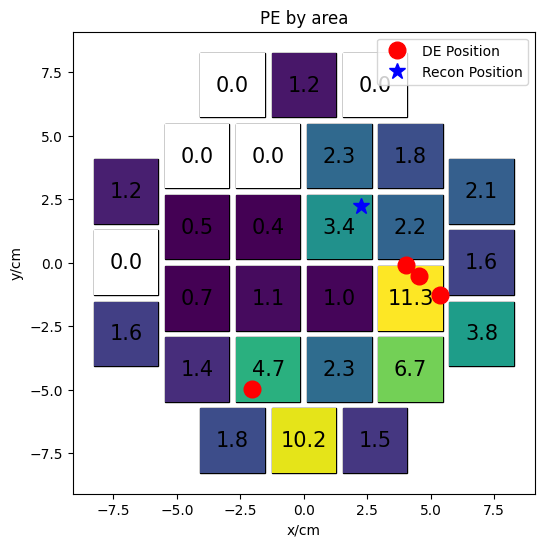

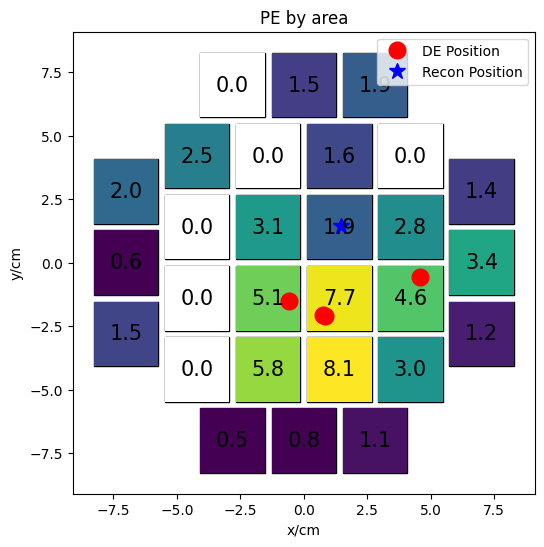

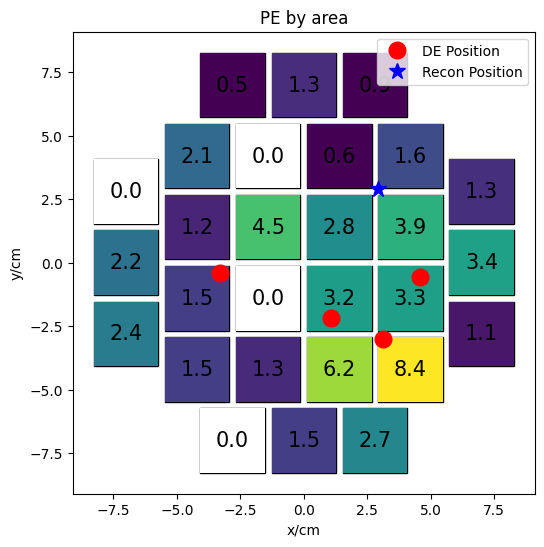

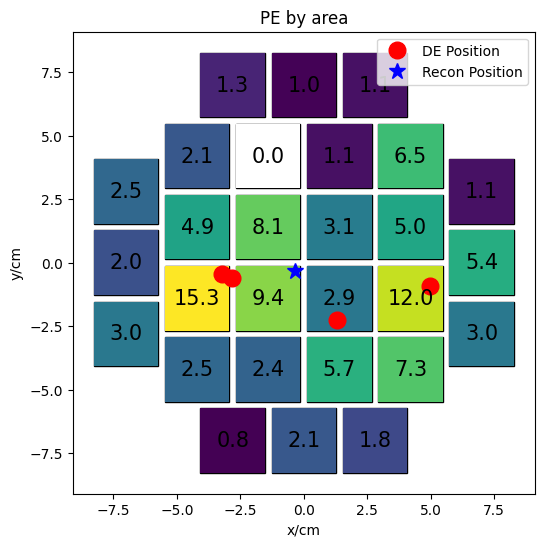

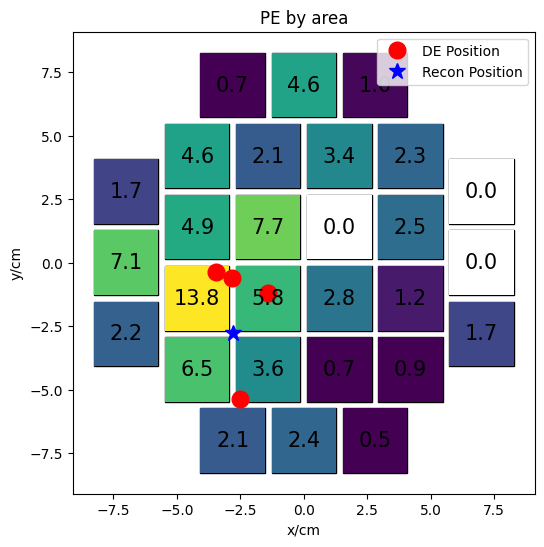

In [20]:
e_num = 4
mask = np.ptp(pipe.pile_up_events[e_num-2]['eventId'], axis=1) != 0 
np.sum(mask)
valid_indices = np.where(mask)[0]

for i in range(min(5, len(valid_indices))):
    idx = valid_indices[i]
# pattern_plot(pipe.pile_up_results[e_num-2].light_pattern[i], electron=[], pos_recons = pipe.pile_up_pos_recon[e_num-2][i], pmt_info = pipe.pmt_top,title = "Pile up light pattern")
    pattern_plot(pipe.pile_up_results[e_num-2].pe_by_area[idx], electron=pipe.pile_up_events[e_num-2][idx], pos_recons = pipe.pile_up_pos_recon[e_num-2][idx], pmt_info = pipe.pmt_top,title = "PE by area")

In [21]:
pattern = np.concatenate(pipe.pile_up_pattern_coef)
st_cor = np.concatenate(pipe.pile_up_st_cor)

In [22]:
len(pattern)

7786990

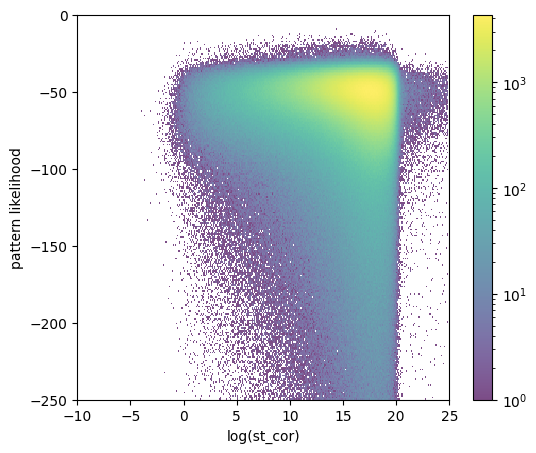

In [23]:
from matplotlib.colors import LogNorm

x_bins = np.arange(-10,25,0.1)
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(st_cor), pattern, bins = (x_bins, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(st_cor)'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)
plt.ylim(-250,0)
plt.show()

In [24]:
from relics_de_sim import DESimConfig, Pipeline
cfg = DESimConfig.from_yaml('../configs/cevns_sim.yaml')
print('cevns_e_spectrum:', cfg.paths.cevns_e_spectrum)

cevns_e_spectrum: /home/leiyang/TPC_DE_SIm-test/data/cevns_sim_20_3e.npz


In [25]:
# from pathlib import Path
# muon_files = [Path(cfg.paths.muon_track_dir) / f'muon_track.{i}.npy' for i in range(4)]
# pipe_cevns = Pipeline(cfg, rng=np.random.default_rng(7))
# pipe_cevns.load_muon_tracks(muon_files)
# print(f'time range: {pipe_cevns.time_range_s:.1f} s')

In [26]:

muon_paths = [str(p) for p in muon_files[:1]]
gamma_paths = [str(p) for p in gamma_files[:0]]
load_files = muon_paths + gamma_paths

pipe_cevns = Pipeline(cfg, rng=np.random.default_rng(7))
pipe_cevns.load_muon_tracks(load_files)
print("loaded file count:", len(load_files))
print(load_files)

Reading muon files:   0%|          | 0/1 [00:00<?, ?it/s]

Reading muon files: 100%|██████████| 1/1 [00:00<00:00, 26.44it/s]


loaded file count: 1
['/home/leiyang/TPC_DE_SIm-test/muon_track/muon_events/muon_events.0.npy']


In [27]:
pipe.time_range_s

11527.714285714286

In [28]:
try:
    pipe_cevns.simulate_cevns()
    for arr in pipe_cevns.cevns_points:
        if len(arr):
            print(f'n_e={int(arr["num_e"][0])}: {len(arr)} events')
except ImportError as exc:
    print('CNN inference unavailable:', exc)

Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 237239/237239 [00:00<00:00, 607748.41it/s]


total samples:  237239 , using a 512 batch for data loader


100%|██████████| 464/464 [00:02<00:00, 218.01it/s]


Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


...

model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 386/386 [00:00<00:00, 464562.80it/s]


total samples:  386 , using a 512 batch for data loader


space-time correlation: 100%|██████████| 1/1 [00:00<00:00, 24.65it/s]

n_e=3: 237239 events
n_e=4: 125580 events
n_e=5: 59381 events
n_e=6: 23488 events
n_e=7: 8315 events
n_e=8: 3048 events
n_e=9: 1086 events
n_e=10: 386 events


In [29]:
arr = np.concatenate(pipe_cevns.cevns_points)

In [30]:
from relics_de_sim.cuts import (
    PatternSTCut,
    fit_pattern_st_cut,
    pattern_likelihood,
)

cevns_st_cor = arr['st_cor']
cevns_pattern = pattern_likelihood(arr['pe_by_area'], arr['recons_light_pattern'], n_top=28)

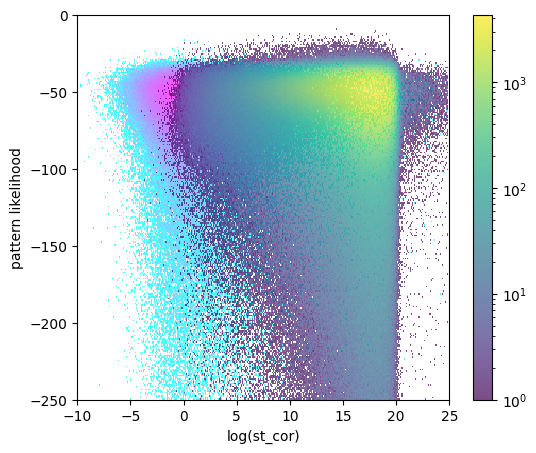

In [31]:
x_bins = np.arange(-10,25,0.1)
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_pattern, bins = (x_bins, y_bins), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), pattern, bins = (x_bins, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(st_cor)'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)
plt.ylim(-250,0)
plt.show()

In [32]:
cevns_area = np.sum(arr['pe_by_area'],axis=1)
cevns_area

array([176.301353  ,  94.66916218, 119.50736779, ..., 268.95251864,
       149.75377244, 248.44319104])

In [33]:
len(pipe.pile_up_results)

6

In [34]:
DE_pe_by_area = []
for i in range(len(pipe.pile_up_results)):
    DE_pe_by_area.append(pipe.pile_up_results[i].pe_by_area)

In [35]:
DE_pe_by_area = np.concatenate(DE_pe_by_area)

In [36]:
DE_area = np.sum(DE_pe_by_area,axis=1)
DE_area

array([101.02397725,  94.22864756,  95.42906885, ..., 263.15284404,
       264.03708069, 172.99845791])

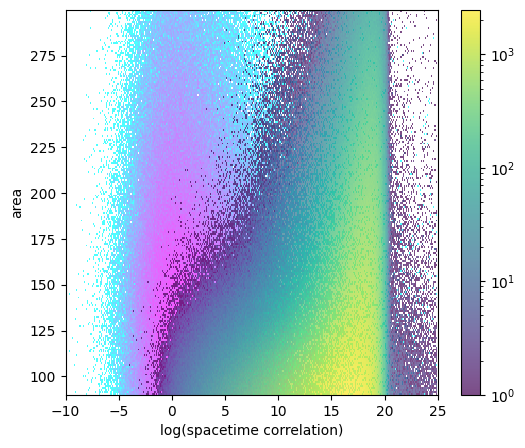

In [37]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_area, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), DE_area, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('area')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)

plt.show()

In [38]:
arr.dtype

dtype([('cevnsID', '<i4'), ('pos_original', [('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8')]), ('t', '<f8'), ('num_e', '<f8'), ('light_pattern', '<f8', (56,)), ('pe_pattern', '<u2', (56,)), ('area_pattern', '<f8', (56,)), ('pe_by_area', '<f8', (56,)), ('pos_recon', [('xd', '<f8'), ('yd', '<f8')]), ('recons_light_pattern', '<f8', (56,)), ('st_cor', '<f8')])

In [39]:
cevns_pe_by_area = arr['pe_by_area']
cevns_pe_by_area.shape

(458523, 56)

/tmp/ipykernel_1046229/634096253.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


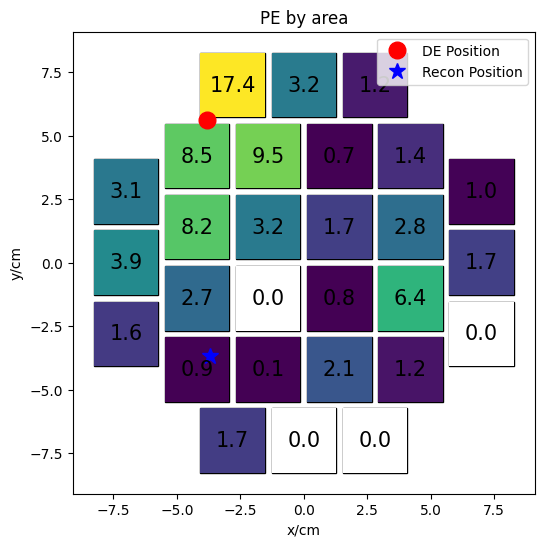

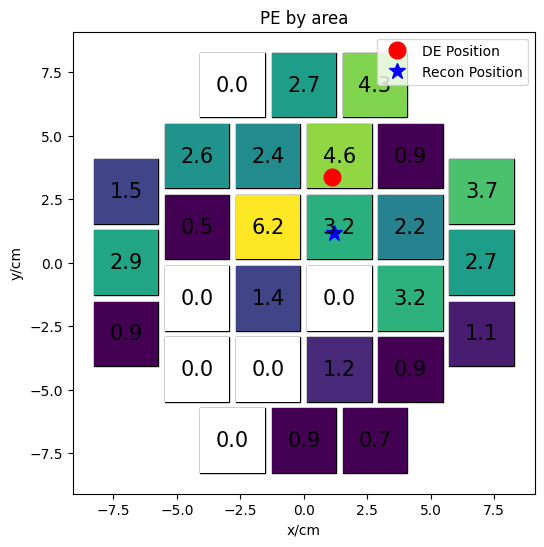

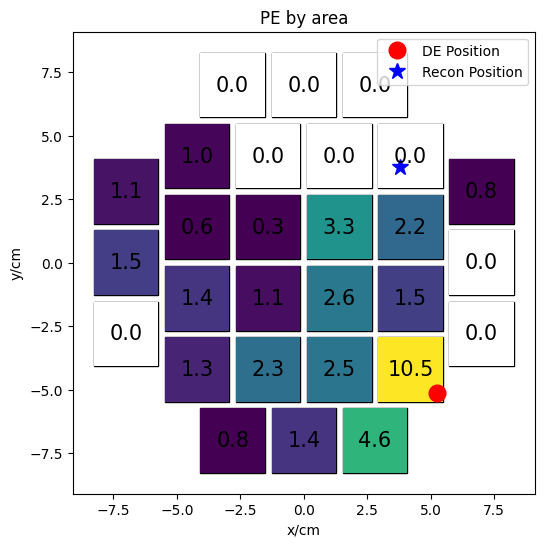

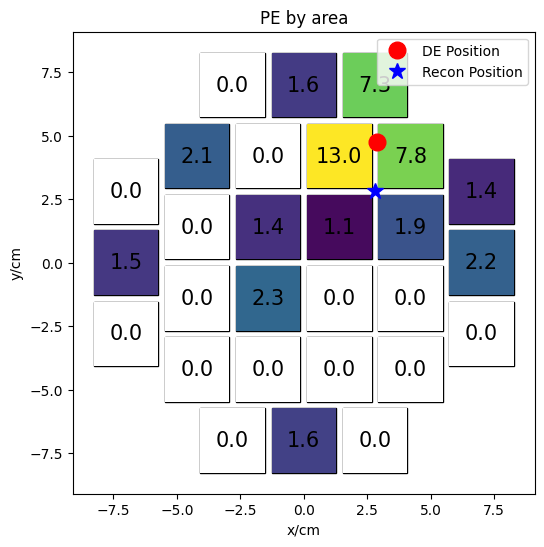

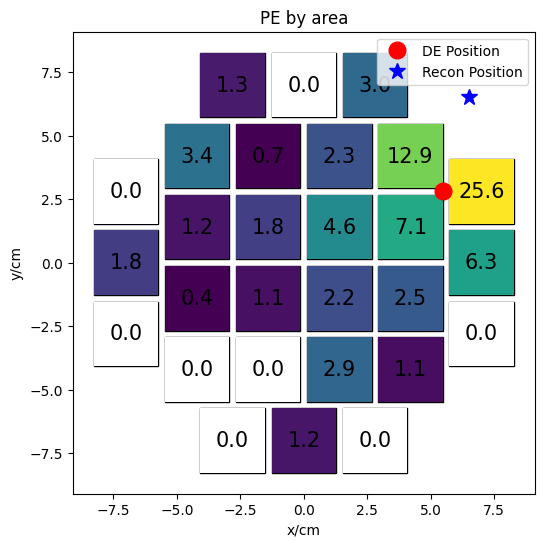

In [40]:
for i in range(5):
    
# pattern_plot(pipe.pile_up_results[e_num-2].light_pattern[i], electron=[], pos_recons = pipe.pile_up_pos_recon[e_num-2][i], pmt_info = pipe.pmt_top,title = "Pile up light pattern")
    pattern_plot(cevns_pe_by_area[i], electron=arr['pos_original'][i], pos_recons = arr['pos_recon'][i], pmt_info = pipe.pmt_top,title = "PE by area")

In [41]:
from tqdm import tqdm

def position_variance(pe_by_area, pmt_info = pipe.pmt_top, n_top=28):

    # 计算每个事件的加权平均位置
    weights = pe_by_area / np.sum(pe_by_area, axis=1, keepdims=True)
    weights_top = weights[:, :n_top]

    pmts = np.array(pmt_info[:n_top])
    
    pos_variance = []
    for item in tqdm(weights_top):
        x_virance = np.std(item*pmts['x'])
        y_virance = np.std(item*pmts['y'])

        pos_variance.append(x_virance**2+y_virance**2)
    return pos_variance

In [42]:
# cevns_pos_virance = position_variance(cevns_pe_by_area)
# DE_pos_virance = position_variance(DE_pe_by_area)

In [43]:
# x_bins = np.arange(-10,25,0.1)

# fig, ax = plt.subplots(figsize=(6, 5))
# h = ax.hist2d(np.log(cevns_st_cor), cevns_pos_virance, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(np.log(st_cor), DE_pos_virance, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
# ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('PMT array variance')
# plt.colorbar(h[3], ax=ax)
# plt.xlim(-10,25)

# plt.show()

In [44]:

# y_bins = np.arange(-250,0,1)

# fig, ax = plt.subplots(figsize=(6, 5))
# h = ax.hist2d(cevns_area, cevns_pos_virance, bins = (200,200), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(DE_area, DE_pos_virance, bins = (200,200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
# ax.set_xlabel('signal size[PE]'); ax.set_ylabel('PMT array variance')
# plt.colorbar(h[3], ax=ax)
# plt.xlim(90,300)
# # plt.ylim(-250,0)
# plt.show()

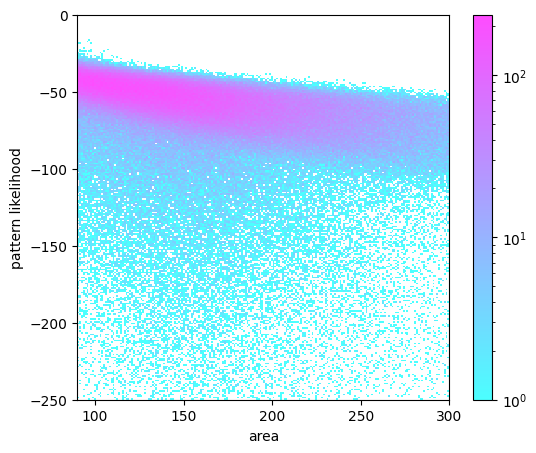

In [45]:
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(cevns_area, cevns_pattern, bins = (200, y_bins), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(DE_area, pattern, bins = (200, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('area'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(90,300)
plt.ylim(-250,0)
plt.show()

In [46]:
def calculate_score(st_cor, area, k_area):
    return  k_area * area - np.log(st_cor)

In [47]:
cevns_ROI_mask = (cevns_area>120) & (cevns_area<240)
DE_ROI_mask = (DE_area>120) & (DE_area<240)

In [48]:
from tqdm import tqdm

exposure = []

k_area_list = np.arange(-0.1,0.4,0.005)
k_list = []
exposure_k = []
for k in tqdm(k_area_list):
    score_cevns = calculate_score(cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area = k)
    score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area = k)
    valid_score_cevns = score_cevns[~np.isnan(score_cevns)]
    valid_score_DE = score_DE[~np.isnan(score_DE)]   
    x = np.percentile(valid_score_DE, 100-0.01)
    exposure_k.append(len(valid_score_cevns[valid_score_cevns>x])/len(valid_score_cevns))
    k_list.append([k,x])
    exposure.append(exposure_k)
exposure = np.array(exposure)

100%|██████████| 100/100 [00:13<00:00,  7.25it/s]


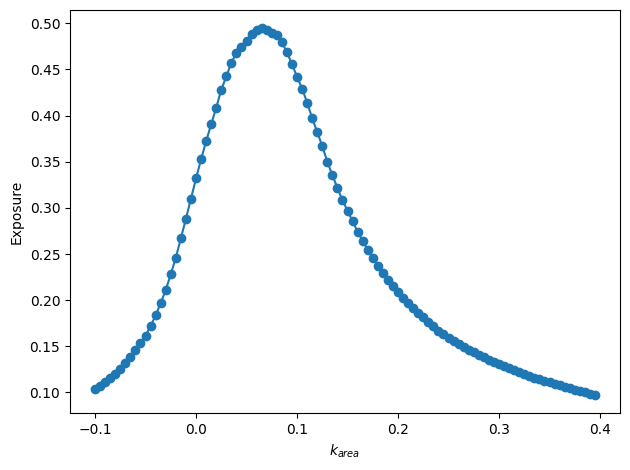

In [49]:
plt.figure()

plt.plot(k_area_list, exposure_k, marker='o')
plt.xlabel(r"$k_{area}$")
plt.ylabel("Exposure")
plt.tight_layout()

plt.show()

In [50]:
index_of_max = np.argmax(exposure)
print(k_list[index_of_max],np.max(exposure))
k_area, b = k_list[index_of_max]
b = -b

[0.06500000000000014, 9.20836503178734] 0.49452588845571416


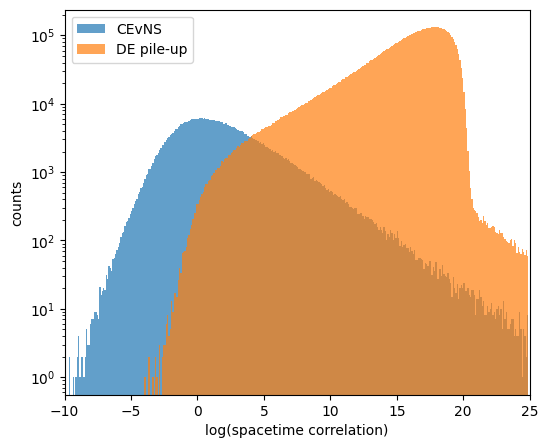

In [51]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist(np.log(cevns_st_cor), bins = x_bins, alpha = 0.7, label = 'CEvNS')
h = ax.hist(np.log(st_cor), bins = x_bins, alpha = 0.7, label = 'DE pile-up')
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('counts')

plt.xlim(-10,25)
plt.yscale('log')
plt.legend()
plt.show()

In [52]:
# thresholds = np.arange(-25, 10, 0.1)  # 你可以调整这个范围和步长以适应你的数据

# # 初始化两个比例的列表
# left_DE_ratios = []
# right_cevns_ratios = []

# # 计算每个阈值下的比例
# for threshold in thresholds:
#     left_DE_ratio = np.sum(-np.log(st_cor) < threshold) / len(np.log(st_cor))
#     right_cevns_ratio = np.sum(-np.log(cevns_st_cor) > threshold) / len(np.log(cevns_st_cor))
    
#     left_DE_ratios.append(left_DE_ratio)
#     right_cevns_ratios.append(right_cevns_ratio)


# left_DE_ratios = np.array(left_DE_ratios)

# if np.any(left_DE_ratios > 1-0.0001):
#     index = np.argmax(left_DE_ratios > 1-0.0001)
# else:
#     index = -1  # 或者 None，表示未找到

# print(index)

# # 导入所需要的库
# import matplotlib.pyplot as plt
# import numpy as np

# cevns_color = '#5882F8'
# DE_color = '#F9885E'

# # 创建一个新的图形并设置大小
# fig, ax1 = plt.subplots(figsize=(8,6))
# plt.rcParams['text.usetex'] = True

# # 开始处理第一个图，使用左侧y轴

# color = 'tab:blue'
# bins = np.arange(-25, 10, 0.1)

# ax1.hist(-np.log(st_cor), bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
# ax1.hist(-np.log(cevns_st_cor), bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
# ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
# ax1.set_xlabel(r'$\mathrm{-log(spacetime\ correlation)}$')  # x轴标签
# ax1.tick_params(axis='y')  # y轴标签颜色

# # 第二个图，使用右侧y轴
# ax2 = ax1.twinx() 
# ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$')  # 左侧y轴标签
# ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
# ax2.plot(thresholds, right_cevns_ratios, label=r'CE$\nu$NS Survival Rate', color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# # ax2.grid(True)
# ax2.tick_params(axis='y')  # y轴标签颜色


# # 获得所有子图的 legend labels 和 handles
# lines, labels = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

# # 创建一个全局的legend
# fig.legend(lines + lines2, labels + labels2, loc=(0.10,0.80))
# # fig.legend(lines, labels, loc=(0.17,0.8))

# # fig.tight_layout(pad = 5)  # 使布局紧密
# # plt.title('Pattern Classifier', fontsize=16)  # 图表标题

# plt.axvline(x=thresholds[index], color='red', linestyle='dashed')
# plt.tight_layout() 
# # plt.savefig("classifier_score.png")
# plt.show()  # 显示绘图


In [53]:
score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area)
score_CEvNS = calculate_score(cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area)
score_CEvNS = score_CEvNS[~np.isnan(score_CEvNS)]
score_DE = score_DE[~np.isnan(score_DE)]

In [54]:
thresholds = np.arange(-25, 50, 0.2)  # 你可以调整这个范围和步长以适应你的数据

# 初始化两个比例的列表
left_DE_ratios = []
right_cevns_ratios = []

# 计算每个阈值下的比例
for threshold in thresholds:
    left_DE_ratio = np.sum(score_DE < threshold) / len(score_DE)
    right_cevns_ratio = np.sum(score_CEvNS > threshold) / len(score_CEvNS)
    
    left_DE_ratios.append(left_DE_ratio)
    right_cevns_ratios.append(right_cevns_ratio)

In [55]:
left_DE_ratios = np.array(left_DE_ratios)

if np.any(left_DE_ratios > 1-0.00001):
    index = np.argmax(left_DE_ratios > 1-0.00001)
else:
    index = -1  # 或者 None，表示未找到

print(index)

180


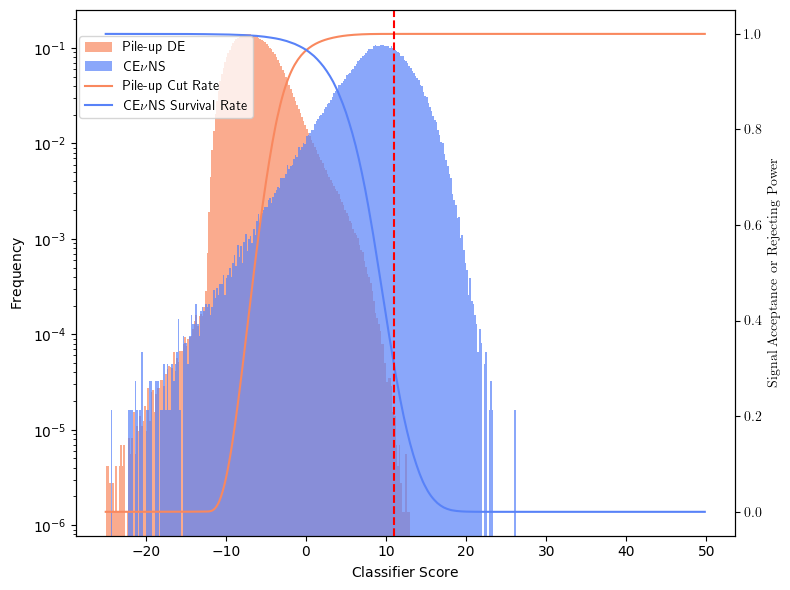

In [56]:
# 导入所需要的库
import matplotlib.pyplot as plt
import numpy as np

cevns_color = '#5882F8'
DE_color = '#F9885E'

# 创建一个新的图形并设置大小
fig, ax1 = plt.subplots(figsize=(8,6))
plt.rcParams['text.usetex'] = True

# 开始处理第一个图，使用左侧y轴

color = 'tab:blue'
bins = np.arange(-25, 50, 0.2)

ax1.hist(score_DE, bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
ax1.hist(score_CEvNS, bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
ax1.set_xlabel(r'$\mathrm{Classifier\ Score}$')  # x轴标签
ax1.tick_params(axis='y')  # y轴标签颜色

# 第二个图，使用右侧y轴
ax2 = ax1.twinx() 
ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$')  # 左侧y轴标签
ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
ax2.plot(thresholds, right_cevns_ratios, label=r'CE$\nu$NS Survival Rate', color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# ax2.grid(True)
ax2.tick_params(axis='y')  # y轴标签颜色


# 获得所有子图的 legend labels 和 handles
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 创建一个全局的legend
fig.legend(lines + lines2, labels + labels2, loc=(0.10,0.80))
# fig.legend(lines, labels, loc=(0.17,0.8))

# fig.tight_layout(pad = 5)  # 使布局紧密
# plt.title('Pattern Classifier', fontsize=16)  # 图表标题

plt.axvline(x=thresholds[index], color='red', linestyle='dashed')
plt.tight_layout() 
# plt.savefig("classifier_score.png")
plt.show()  # 显示绘图


In [57]:
pipe.time_range_s

11527.714285714286

In [58]:
sel_thres = thresholds[index]
sel_thres

10.999999999999872

In [59]:
def plot_area_spectrum(area, total_time, LXe_mass, bins, **kwargs):
    """
    Plot area spectrum. Frequency (y axis) is converted to [Hz/10^3 PE].
    """
    
    # get area frequency and convert to Hz/10^3 PE
    count, bins = np.histogram(area, bins=bins)
    bin_width = np.diff(bins)
    freq = count / (bin_width) / total_time / LXe_mass
    err = np.sqrt(count)
    # create canvas
    ax = plt.gca() # get current axes
    
    # plot spectrum
    ax.stairs(freq, edges=bins, **kwargs)
    ax.set_xlabel('area [PE]')
    ax.set_ylabel('Freq [Hz/(kg*PE)]')
    
    return ax, count, bins

In [60]:
DE_cut = score_DE > sel_thres

Text(0.5, 1.0, 'Pile-up DE area spectrum')

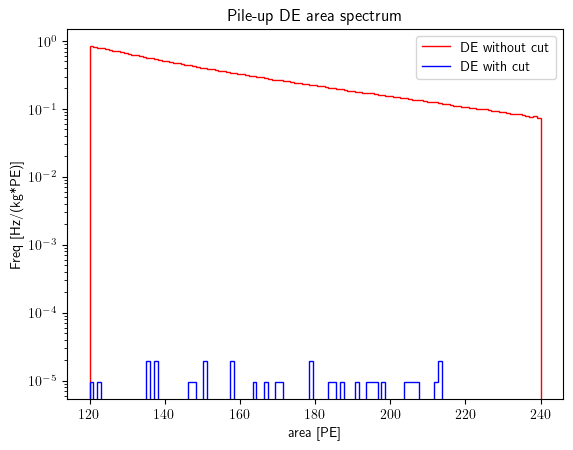

In [61]:
bins = np.linspace(120,240,120)
total_time = pipe.time_range_s
plot_area_spectrum(DE_area[DE_ROI_mask], total_time, LXe_mass=8.98, bins=bins, label='DE without cut', color='red')
plot_area_spectrum(DE_area[DE_ROI_mask][DE_cut], total_time, LXe_mass=8.98, bins=bins, label='DE with cut', color='blue')
plt.yscale('log')
plt.legend()
plt.title('Pile-up DE area spectrum')

In [69]:
len(DE_area[DE_ROI_mask][DE_cut])

33

In [66]:
(len(DE_area[DE_ROI_mask][DE_cut])/total_time)*3600*24*365

90277.04662056657

In [68]:
len(DE_area[DE_ROI_mask][DE_cut])/total_time

0.002862666369246784

In [65]:
len(DE_area)

7786990